In [ ]:
!pip install gdown

In [ ]:
# Download
!gdown 15Py3AKyGzWNX4M3OJKlQQsnH6IehkoEd -O local/data/image_segmentation_model.pth            # model
!gdown 17eJ6aei6yBAbK1aA4mhTeMdXYycorqcT -O local/data/image_segmentation_model_cfg.json       # configuration
!gdown 1spXt5_ISG1ZaHHO2DTtCSqgkohnhwuzt -O local/data/image_segmentation_model_ontology.json  # ontology

In [ ]:
from perceptionmetrics.models.torch_segmentation import TorchImageSegmentationModel

model = TorchImageSegmentationModel(
    model="local/data/image_segmentation_model.pth",                        
    model_cfg="local/data/image_segmentation_model_cfg.json",
    ontology_fname="local/data/image_segmentation_model_ontology.json",
)

In [5]:
## NuImages Segmentation Dataset and Model

import json
from pathlib import Path

from perceptionmetrics.models.torch_segmentation import TorchImageSegmentationModel
from perceptionmetrics.datasets.nuimages import NuImagesSegmentationDataset

dataset = NuImagesSegmentationDataset(
    dataset_dir="local/data/nuimages-v1.0-mini", version="v1.0-mini", split="train"
)

# Build compact ontology (contiguous idx: 0..N-1) to avoid sparse-index issues (e.g., idx 31).
sorted_items = sorted(dataset.ontology.items(), key=lambda x: x[1]["idx"] )
compact_ontology = {
    class_name: {
        "idx": new_idx,
        "rgb": class_meta.get("rgb", [0, 0, 0]),
    }
    for new_idx, (class_name, class_meta) in enumerate(sorted_items)
}

ontology_path = Path("local/data/nuimages_segmentation_ontology_compact.json")
ontology_path.parent.mkdir(parents=True, exist_ok=True)
with open(ontology_path, "w") as f:
    json.dump(compact_ontology, f, indent=2)

max_idx = max(v["idx"] for v in compact_ontology.values())
print(
    f"Saved compact ontology to {ontology_path} with {len(compact_ontology)} classes (max idx={max_idx})"
 )

model = TorchImageSegmentationModel(
    model="local/data/image_segmentation_model.pth",
    model_cfg="local/data/image_segmentation_model_cfg.json",
    ontology_fname=str(ontology_path),
)

Built nuImages segmentation dataset with 50 samples and 26 classes.
Saved compact ontology to local/data/nuimages_segmentation_ontology_compact.json with 26 classes (max idx=25)


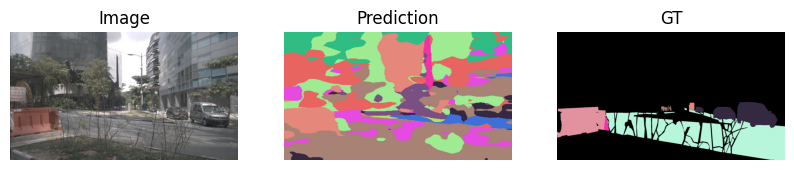

In [6]:
from matplotlib import pyplot as plt
import numpy as np
from PIL import Image

from perceptionmetrics.utils import conversion as uc

image_fname = dataset.dataset["image"].iloc[0]
image = Image.open(image_fname)

label_fname = dataset.dataset["label"].iloc[0]
label = Image.open(label_fname)
label = uc.label_to_rgb(label, dataset.ontology)

pred = model.predict(image)
pred = uc.label_to_rgb(pred, model.ontology)
pred = pred.resize(label.size)

plt.figure(figsize=(10, 10))
plt.subplot(131), plt.title("Image"), plt.imshow(np.array(image)), plt.axis("off")
plt.subplot(132), plt.title("Prediction"), plt.imshow(np.array(pred)), plt.axis("off")
plt.subplot(133), plt.title("GT"), plt.imshow(np.array(label)), plt.axis("off")
plt.show()

In [ ]:
# Inspect overlap first
model_classes = set(model.ontology.keys())
dataset_classes = set(dataset.ontology.keys())
print("Model classes:", len(model_classes))
print("Dataset classes:", len(dataset_classes))
print(
    "Overlap:",
    len(model_classes & dataset_classes),
    sorted(model_classes & dataset_classes)[:20],
)

# Build a safe translation map
# old_ontology = dataset.ontology, new_ontology = model.ontology
# dataset ontology -> model ontology
fallback = list(model.ontology.keys())[0]
ontology_translation = {
    class_name: (class_name if class_name in model.ontology else fallback)
    for class_name in dataset.ontology.keys()
}

# TorchImageSegmentationModel.eval expects a JSON filename, not a Python dict.
translation_path = Path("local/data/nuimages_to_model_ontology_translation.json")
translation_path.parent.mkdir(parents=True, exist_ok=True)
with open(translation_path, "w", encoding="utf-8") as f:
    json.dump(ontology_translation, f, indent=2)

results = model.eval(
    dataset,
    split="train",
    ontology_translation=str(translation_path),
)
display(results)